In [3]:
import os
import sys
import random
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

# Seeds
SEED = 58
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Add parent directory to path for imports (notebook context doesn't have __file__)
sys.path.insert(0, os.path.abspath(".."))
for mod in list(sys.modules.keys()):
    if "base" in mod or "data_loader" in mod or "ModelWrapper" in mod or "benchmark" in mod:
        del sys.modules[mod]

# Auto-configure paths from centralized config
from benchmark_config import (
    PROJECT_ROOT, SRC_ROOT, ADBENCH_ROOT, ADBENCH_DATASETS,
    DATASET_CONFIG, TEST_SCENARIOS, EVAL_DATASETS,
    get_scenario, get_model_config
)

# Ensure paths are in sys.path
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if str(ADBENCH_ROOT) not in sys.path:
    sys.path.append(str(ADBENCH_ROOT))

from utils import create_models, validate_data

import base
base = reload(base)
from base import Model, Data, CoLearning
from colearner import SimpleCoLearner, SingleModel, CoLearnerVal
from strategy import SimpleStrategy, PlateauStrategy, AdaptivePlateauStrategy, RecurrentPlateauStrategy
import baselines.adbench.ModelWrapperADBench as mw
mw = reload(mw)
from baselines.adbench.ModelWrapperADBench import PYOD_AVAILABLE
from baselines.adbench.data_loader import ClassicalADBenchData, load_data

# Data loading configuration
TRAIN_SPLIT = 0.8
VAL_TEST_SPLIT = 0.02
SEMI_LABEL_RATIO = 1
SEMI_STRATIFIED = True
PRESERVE_LABELED = True

print(f"Paths: root={PROJECT_ROOT.name}, data={ADBENCH_DATASETS}")
print(f"Config: train={TRAIN_SPLIT} val_test={VAL_TEST_SPLIT} semi={SEMI_LABEL_RATIO} strat={SEMI_STRATIFIED} preserve={PRESERVE_LABELED}")

Paths: root=CoBench, data=/home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical
Config: train=0.8 val_test=0.02 semi=1 strat=True preserve=True


pip uninstall scikit-learn pyod -y
pip install --no-cache-dir scikit-learn==1.0.2
pip install --no-cache-dir pyod==1.0.9

In [4]:
# Use centralized path configuration
DATASET_PATH = DATASET_CONFIG["path"]

data = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
    random_state=SEED)

# Benchmark integrity checks
validate_data(data)

labels = data.semisupervised_labels
n_real = int(np.sum(labels != -1))
n_false = int(np.sum(labels == -1))

print(f"Data: train={data.n_train} val={data.n_val} test={data.n_test} d={data.X_train.shape[1]} at {DATASET_PATH}")
print(f"original labels: among {data.n_train} really labeled ={int(np.sum(labels!=-1))} unlabeled (-1) = {int(np.sum(labels==-1))}")
print(f"unlabeled_policy: {data.unlabeled_policy}")

Data: train=273241 val=66945 test=1366 d=12 at /home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical/bnp_tabular_labeled.npz.zip
original labels: among 273241 really labeled =273241 unlabeled (-1) = 0
unlabeled_policy: unlabeled_as_normal


In [5]:
model_to_test = "prenet"
model_names = ["prenet", "deepsad"]
recurrent_model = ["gru"] #TODO flexible way of changing the recurrent model 

In [6]:
#TEST 1 : solo model train, quick check to see if it learns, if the loss (if available) gets minimized
#TODO, iterate on the models in model_names instead of only moddel_to_test 
registry = mw.get_model_detector_dict()
results_summary = {}

prenet_cls = registry[model_to_test]
print(f"Model: {prenet_cls.__name__}")

train_config = {"total_epochs": 2, "batch_size": 256}
prenet = prenet_cls(train_config=train_config, model_config={}, data=data)

for epoch in range(5):
    prenet.train(1)
    scores = prenet.predict_scores()
    auc_score = roc_auc_score(data.y_test, scores)
    loss = None
    if hasattr(prenet, "get_loss"):
        try:
            loss = prenet.get_loss()
        except TypeError:
            loss = None
    loss_str = f" loss={loss:.4f}" if loss is not None else ""
    print(f"epoch {epoch} auc={auc_score:.4f}{loss_str}")

results_summary[model_to_test] = auc_score
print(f"Summary: {model_to_test} auc={auc_score:.4f}")

Model: PReNetWrapper
epoch 0 auc=0.5418 loss=0.9874
epoch 1 auc=0.5632 loss=0.9817
epoch 2 auc=0.5823 loss=0.9753
epoch 3 auc=0.6047 loss=0.9668
epoch 4 auc=0.6255 loss=0.9558
Summary: prenet auc=0.6255


In [ ]:
#TEST 2 : check if co-learning and its strategy work, 
registry = mw.get_model_detector_dict()

CoLearnerClass = CoLearnerVal

data_test1 = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
    random_state=SEED,
)

print(f"TEST1 solo vs {CoLearnerClass.__name__}: {model_names}")

models = create_models(registry, model_names, data_test1)
solo_results = {}

for i, model in enumerate(models):
    model.fit()
    scores = model.predict_scores()
    auc = roc_auc_score(data_test1.y_test, scores)
    solo_results[f"model_{i}"] = auc

print("Solo AUCs: " + ", ".join([f"{k}={v:.4f}" for k, v in solo_results.items()]))

strategy = PlateauStrategy(metric_key="ensemble", mode="max", patience=5, min_delta=0.001)
colearner = CoLearnerClass(
    models=models,
    data=data_test1,
    strategy=strategy,
    warmup_epochs=1,
    max_chapters=3,
    anomaly_threshold=0.5,
    confidence_threshold_low=0.05,
    confidence_threshold_high=0.95,
 )
history = colearner.cotrain(eval_interval=1)

collab_metrics = {}
for i, model in enumerate(models):
    test_scores = model.predict_scores()
    collab_metrics[f"model_{i}"] = roc_auc_score(data_test1.y_test, test_scores)
ensemble_scores = np.mean([model.predict_scores() for model in models], axis=0)
collab_metrics["ensemble"] = roc_auc_score(data_test1.y_test, ensemble_scores)

for key, value in collab_metrics.items():
    solo_val = solo_results.get(key, 0.0)
    delta = value - solo_val
    print(f"{key}: solo={solo_val:.4f} collab={value:.4f} delta={delta:+.4f}")

TEST1 solo vs CoLearnerVal: ['prenet', 'deepsad']


In [ ]:
print("TEST3 pseudo-labels")
print(f"original labels: among {data.n_train} | anomalies = {int(np.sum(labels==1))} | normals = {int(np.sum(labels==0))} | unlabeled (-1) = {int(np.sum(labels==-1))}")
for model_idx, model in enumerate(models):
    pseudo_labels = model._pseudo_labels
    n_pseudo, n_normal, n_anomaly = np.sum(pseudo_labels != -1), np.sum(pseudo_labels == 0),np.sum(pseudo_labels == 1)
    print(f"{model.__class__.__name__}: total={n_pseudo} normal={n_normal} anomaly={n_anomaly} | proportion = {round(100*(n_normal+n_anomaly)/int(np.sum(labels==-1)),4)}%")

TEST3 pseudo-labels
original labels: among 4320 | anomalies = 32 | normals = 400 | unlabeled (-1) = 3888
PReNetWrapper: total=3605 normal=3605 anomaly=0 | proportion = 92.7212%
DeepSADWrapper: total=9 normal=7 anomaly=2 | proportion = 0.2315%


We then test with the judge model

In [ ]:
# GRU Recurrent Ensemble Test
from importlib import reload

import colearner as colearner_mod
import recurrentmodels as recurrentmodels_mod
colearner_mod = reload(colearner_mod)
recurrentmodels_mod = reload(recurrentmodels_mod)
from colearner import DelayedRecurrentCoLearner
from recurrentmodels import GRURecurrentModel
from strategy import RecurrentPlateauStrategy
from utils import extract_embeddings_auto

registry = mw.get_model_detector_dict()

model_names_gru = ["prenet", "deepsad"]
data_gru = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
    random_state=SEED,
 )

models_gru = create_models(registry, model_names_gru, data_gru)
gru_model = GRURecurrentModel(
    hidden_size=128,
    num_layers=1,
    dropout=0.0,
    lr=1e-3,
    batch_size=256,
    num_epochs=5,
    seed=SEED,
    n_detectors=len(models_gru),
 )

# GRU-aware strategy: monitors detector ensemble before GRU starts,
# then switches to monitoring GRU AUC once the judge model is active
strategy_gru = RecurrentPlateauStrategy(
    recurrent_start_chapter=3,
    fallback_key="ensemble",
    recurrent_key="gru",
    mode="max",
    patience_fallback=5,
    patience_recurrent=3,
    min_delta=0.001,
)

colearner_gru = DelayedRecurrentCoLearner(
    models=models_gru,
    data=data_gru,
    strategy=strategy_gru,
    recurrent_model=gru_model,
    warmup_epochs=10,
    max_chapters=10,
    embeddings_aggregate="stack",
    recurrent_start_chapter=3,
 )

# Val loss is now computed automatically by the colearner with fresh embeddings
history_gru = colearner_gru.cotrain(eval_interval=1)

colearner_gru.embeddings_use_train = False
test_embeddings = colearner_gru._collect_embeddings(indexes=None)
gru_scores = gru_model.predict_scores(test_embeddings)
gru_auc = roc_auc_score(data_gru.y_test, gru_scores)
print(f"GRU Recurrent Model Test AUC on {DATASET_CONFIG['name']}: {gru_auc:.4f}")

GRU Recurrent Model Test AUC on annthyroid: 0.8132


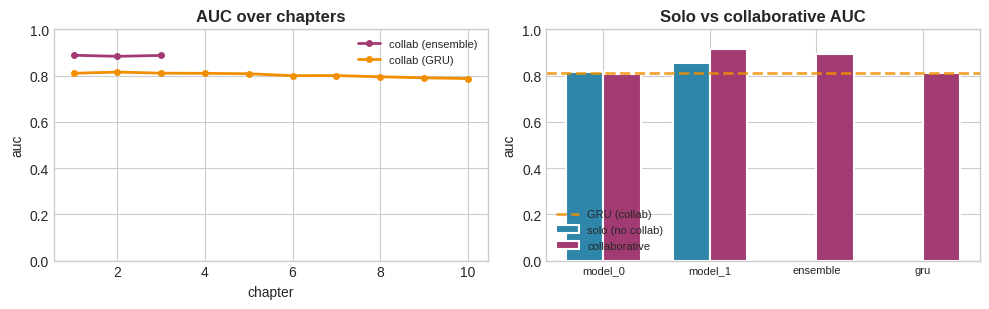

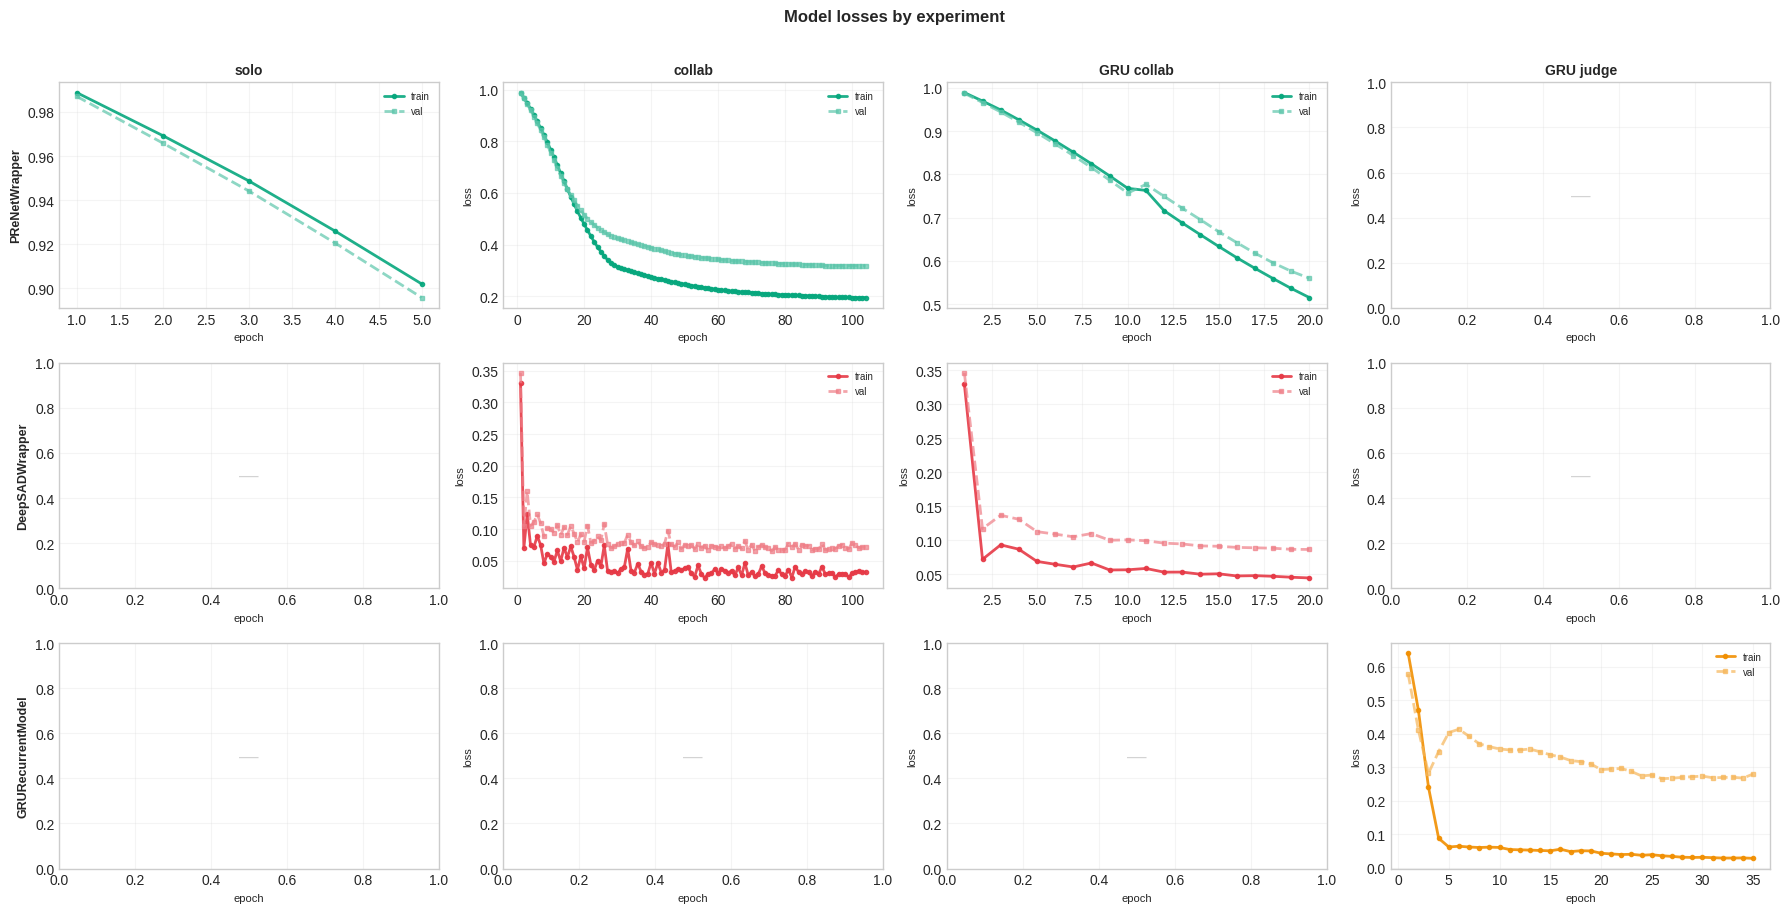

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict, OrderedDict
%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "solo": "#2E86AB",
    "collab": "#A23B72",
    "gru": "#F18F01",
    "prenet": "#06A77D",
    "deepsad": "#E63946",
    "ensemble": "#8338EC",
}

def _lighten_color(color, amount=0.35):
    """Lighten a color by mixing with white."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

def _plot_auc(histories, labels, ax, title):
    colors_map = ["#A23B72", "#F18F01"]
    for i, (hist, label) in enumerate(zip(histories, labels)):
        if not hist or "chapters" not in hist or not hist["chapters"]:
            continue
        chapters = hist["chapters"]
        x = np.arange(1, len(chapters) + 1)
        y = [c.get("ensemble", np.nan) for c in chapters]
        ax.plot(x, y, marker="o", linewidth=2, markersize=4, label=label, color=colors_map[i])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("chapter"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)

def _plot_solo_vs_collab(solo, collab, gru_val, ax, title):
    if not solo or not collab:
        return
    keys = [k for k in collab.keys() if k in solo]
    if "ensemble" in collab:
        keys.append("ensemble")
    labels = keys + (["gru"] if gru_val is not None else [])
    solo_vals = [solo.get(k, np.nan) for k in keys] + ([np.nan] if gru_val is not None else [])
    collab_vals = [collab.get(k, np.nan) for k in keys] + ([gru_val] if gru_val is not None else [])
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x - w/2, solo_vals, width=w, label="solo (no collab)", color=COLORS["solo"], edgecolor="white", linewidth=1.5)
    ax.bar(x + w/2, collab_vals, width=w, label="collaborative", color=COLORS["collab"], edgecolor="white", linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    if gru_val is not None and not np.isnan(gru_val):
        ax.axhline(y=gru_val, color=COLORS["gru"], linestyle="--", linewidth=2, label="GRU (collab)", alpha=0.8)
    ax.legend(fontsize=8, loc="best")

# ── AUC overview ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
_plot_auc([history, history_gru], ["collab (ensemble)", "collab (GRU)"], axes[0], "AUC over chapters")
_plot_solo_vs_collab(solo_results, collab_metrics, gru_auc if 'gru_auc' in globals() else None, axes[1], "Solo vs collaborative AUC")
fig.tight_layout(); plt.show()

# ── Loss mosaic: rows = model type, cols = experiment ──
color_map = {
    "PReNetWrapper": COLORS["prenet"],
    "DeepSADWrapper": COLORS["deepsad"],
    "GRURecurrentModel": COLORS["gru"],
}
experiments = OrderedDict([
    ("solo", [prenet]),
    ("collab", models if 'models' in globals() else []),
    ("GRU collab", models_gru if 'models_gru' in globals() else []),
])
# Build grid[model_type][experiment] = model
grid = OrderedDict()
for exp, ms in experiments.items():
    ms = ms if isinstance(ms, list) else [ms]
    for m in ms:
        name = m.__class__.__name__
        grid.setdefault(name, OrderedDict())[exp] = m
# Append GRU judge as its own row
grid["GRURecurrentModel"] = {"GRU judge": gru_model}

row_names = list(grid.keys())
col_set = []
for row_data in grid.values():
    for c in row_data:
        if c not in col_set:
            col_set.append(c)

nrows = len(row_names)
ncols = len(col_set)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)

for r, model_type in enumerate(row_names):
    row_data = grid[model_type]
    color = color_map.get(model_type, "#555555")
    for c, exp in enumerate(col_set):
        ax = axes[r][c]
        m = row_data.get(exp)
        has = False
        if m is not None:
            train = getattr(m, "_train_loss_history", None)
            val = getattr(m, "_val_loss_history", None)
            if train:
                ax.plot(np.arange(1, len(train)+1), train, marker="o", linewidth=2,
                        markersize=3, color=color, label="train", alpha=0.9)
                has = True
            if val:
                val_c = _lighten_color(color, 0.35)
                ax.plot(np.arange(1, len(val)+1), val, marker="s", linewidth=2,
                        markersize=3, color=val_c, linestyle="--", label="val", alpha=0.7)
                has = True
            if not has:
                last = getattr(m, "_last_loss", None)
                if last is not None:
                    ax.plot([1], [last], marker="o", markersize=6, color=color, label="last loss")
                    has = True
        if has:
            ax.legend(fontsize=7, loc="best")
        else:
            ax.text(0.5, 0.5, "—", ha="center", va="center", transform=ax.transAxes, fontsize=14, color="lightgray")
        ax.set_xlabel("epoch", fontsize=8); ax.set_ylabel("loss", fontsize=8)
        ax.grid(True, alpha=0.2)
        # Row / col headers
        if c == 0:
            ax.set_ylabel(model_type, fontsize=9, fontweight="bold")
        if r == 0:
            ax.set_title(exp, fontweight="bold", fontsize=10)

fig.suptitle("Model losses by experiment", fontweight="bold", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CROSS-VALIDATION BENCHMARK  –  N trials, different random seeds
# Evaluates: solo baselines · collaborative (CoLearnerVal) · GRU judge
# Stores: AUC, AP, loss histories, per-chapter AUCs → ready for plotting
# ══════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, average_precision_score
from utils import extract_embeddings_auto
import time

N_TRIALS       = 3
CV_WARMUP      = 20
CV_MAX_CHAP    = 15
CV_EP_PER_CHAP = 3
CV_GRU_START   = 3

registry = mw.get_model_detector_dict()

# ── Result storage (lists indexed by trial) ──
cv_results = {
    "n_trials": N_TRIALS,
    "dataset": str(DATASET_PATH),
    "model_names": list(model_names),
    "seeds": [],
    # Solo baselines: per model name
    "solo": {n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
             for n in model_names},
    # Collaborative: per model name + "ensemble"
    "collab": {n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
               for n in list(model_names) + ["ensemble"]},
    "collab_chapters": [],          # list[trial] of cotrain history dicts
    "collab_val_loss": [],          # list[trial] of {model_idx: [loss_per_epoch]}
    # GRU recurrent judge
    "gru": {"auc": [], "ap": [], "train_loss": [], "val_loss": [],
            "chapters": []},        # list[trial] of gru cotrain history
}

t_total = time.time()

for trial_idx in range(N_TRIALS):
    seed = SEED + trial_idx
    cv_results["seeds"].append(seed)
    t0 = time.time()
    print(f"\n{'─'*60}\n Trial {trial_idx + 1}/{N_TRIALS}  (seed={seed})")

    trial_data = ClassicalADBenchData(
        DATASET_PATH,
        train_test_split_ratio=TRAIN_SPLIT,
        val_test_split_ratio=VAL_TEST_SPLIT,
        preserve_labeled=PRESERVE_LABELED,
        labeled_ratio=SEMI_LABEL_RATIO,
        stratified=SEMI_STRATIFIED,
        random_state=seed,
    )

    # ── 1. SOLO BASELINES ──────────────────────────────────────────
    for name in model_names:
        solo_m = create_models(registry, [name], trial_data)[0]
        solo_m.fit()
        sc = solo_m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap  = average_precision_score(trial_data.y_test, sc)
        cv_results["solo"][name]["auc"].append(auc)
        cv_results["solo"][name]["ap"].append(ap)
        cv_results["solo"][name]["train_loss"].append(
            getattr(solo_m, "_train_loss_history", []).copy())
        cv_results["solo"][name]["val_loss"].append(
            getattr(solo_m, "_val_loss_history", []).copy())
        print(f"  Solo  {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    # ── 2. COLLABORATIVE (CoLearnerVal) ────────────────────────────
    collab_models = create_models(registry, model_names, trial_data)
    collab_strat = PlateauStrategy(patience=5, mode="max", min_delta=0.001)
    collab_cl = CoLearnerVal(
        models=collab_models, data=trial_data, strategy=collab_strat,
        warmup_epochs=CV_WARMUP, max_chapters=CV_MAX_CHAP,
        epochs_per_chapter=CV_EP_PER_CHAP,
    )
    collab_hist = collab_cl.cotrain(eval_interval=1)
    cv_results["collab_chapters"].append(collab_hist)
    cv_results["collab_val_loss"].append(
        {k: v.copy() for k, v in collab_cl.val_loss_history.items()})

    for name, m in zip(model_names, collab_models):
        sc  = m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap  = average_precision_score(trial_data.y_test, sc)
        cv_results["collab"][name]["auc"].append(auc)
        cv_results["collab"][name]["ap"].append(ap)
        cv_results["collab"][name]["train_loss"].append(
            getattr(m, "_train_loss_history", []).copy())
        cv_results["collab"][name]["val_loss"].append(
            getattr(m, "_val_loss_history", []).copy())
        print(f"  Collab {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    ens_sc  = np.mean([m.predict_scores() for m in collab_models], axis=0)
    ens_auc = roc_auc_score(trial_data.y_test, ens_sc)
    ens_ap  = average_precision_score(trial_data.y_test, ens_sc)
    cv_results["collab"]["ensemble"]["auc"].append(ens_auc)
    cv_results["collab"]["ensemble"]["ap"].append(ens_ap)
    print(f"  Collab ensemble   AUC={ens_auc:.4f}  AP={ens_ap:.4f}")

    # ── 3. GRU RECURRENT JUDGE ─────────────────────────────────────
    try:
        gru_models = create_models(registry, model_names, trial_data)
        gru_m = GRURecurrentModel(
            hidden_size=128, num_layers=1, dropout=0.0, lr=1e-3,
            batch_size=256, num_epochs=5, seed=seed,
            n_detectors=len(gru_models),
        )
        gru_strat = RecurrentPlateauStrategy(
            recurrent_start_chapter=CV_GRU_START, fallback_key="ensemble",
            recurrent_key="gru", mode="max",
            patience_fallback=5, patience_recurrent=3, min_delta=0.001,
        )
        gru_cl = DelayedRecurrentCoLearner(
            models=gru_models, data=trial_data, strategy=gru_strat,
            recurrent_model=gru_m, warmup_epochs=CV_WARMUP,
            max_chapters=CV_MAX_CHAP, embeddings_aggregate="stack",
            recurrent_start_chapter=CV_GRU_START,
        )

        # Val loss is now computed automatically by the colearner
        hist_gru = gru_cl.cotrain(eval_interval=1)

        # Final GRU test evaluation
        gru_cl.embeddings_use_train = False
        test_emb = gru_cl._collect_embeddings(indexes=None)
        gru_sc = gru_m.predict_scores(test_emb)
        g_auc = roc_auc_score(trial_data.y_test, gru_sc)
        g_ap  = average_precision_score(trial_data.y_test, gru_sc)
        cv_results["gru"]["auc"].append(g_auc)
        cv_results["gru"]["ap"].append(g_ap)
        cv_results["gru"]["train_loss"].append(
            getattr(gru_m, "_train_loss_history", []).copy())
        cv_results["gru"]["val_loss"].append(
            getattr(gru_m, "_val_loss_history", []).copy())
        cv_results["gru"]["chapters"].append(hist_gru)
        print(f"  GRU judge      AUC={g_auc:.4f}  AP={g_ap:.4f}")
    except Exception as exc:
        print(f"  ⚠ GRU FAILED: {exc}")
        cv_results["gru"]["auc"].append(np.nan)
        cv_results["gru"]["ap"].append(np.nan)
        cv_results["gru"]["train_loss"].append([])
        cv_results["gru"]["val_loss"].append([])
        cv_results["gru"]["chapters"].append({"chapters": []})

    print(f"  ⏱ {time.time() - t0:.1f}s")

# ══════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'='*72}")
print(f"  CROSS-VALIDATION SUMMARY  ({N_TRIALS} trials · {DATASET_CONFIG['name']})")
print(f"{'='*72}")
print(f"  {'Method':<26} {'AUC (mean±std)':<22} {'AP (mean±std)':<22}")
print(f"  {'-'*68}")

for name in model_names:
    a = np.array(cv_results["solo"][name]["auc"])
    p = np.array(cv_results["solo"][name]["ap"])
    print(f"  Solo {name:<20} {a.mean():.4f} ± {a.std():.4f}     {p.mean():.4f} ± {p.std():.4f}")
print(f"  {'-'*68}")

for name in list(model_names) + ["ensemble"]:
    a = np.array(cv_results["collab"][name]["auc"])
    p = np.array(cv_results["collab"][name]["ap"])
    tag = f"Collab {name}"
    print(f"  {tag:<26} {a.mean():.4f} ± {a.std():.4f}     {p.mean():.4f} ± {p.std():.4f}")
print(f"  {'-'*68}")

ga = np.array(cv_results["gru"]["auc"])
gp = np.array(cv_results["gru"]["ap"])
print(f"  {'GRU recurrent':<26} {np.nanmean(ga):.4f} ± {np.nanstd(ga):.4f}     {np.nanmean(gp):.4f} ± {np.nanstd(gp):.4f}")

# Deltas (collab - solo)
print(f"\n  {'Δ (collab − solo)':<26} {'ΔAUC':<22} {'ΔAP':<22}")
print(f"  {'-'*68}")
for name in model_names:
    da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
    dp = np.array(cv_results["collab"][name]["ap"])  - np.array(cv_results["solo"][name]["ap"])
    print(f"  {name:<26} {da.mean():+.4f} ± {da.std():.4f}     {dp.mean():+.4f} ± {dp.std():.4f}")

# GRU vs ensemble delta
if not np.all(np.isnan(ga)):
    d_gru_ens_auc = ga - np.array(cv_results["collab"]["ensemble"]["auc"])
    d_gru_ens_ap  = gp - np.array(cv_results["collab"]["ensemble"]["ap"])
    print(f"\n  {'Δ (GRU − ensemble)':<26} {'ΔAUC':<22} {'ΔAP':<22}")
    print(f"  {'-'*68}")
    print(f"  {'GRU judge':<26} {np.nanmean(d_gru_ens_auc):+.4f} ± {np.nanstd(d_gru_ens_auc):.4f}     {np.nanmean(d_gru_ens_ap):+.4f} ± {np.nanstd(d_gru_ens_ap):.4f}")

print(f"\n  Total time: {time.time() - t_total:.1f}s")
print(f"  cv_results dict ready for plotting in next cells")


────────────────────────────────────────────────────────────
 Trial 1/3  (seed=58)
  Solo  prenet     AUC=0.8168  AP=0.4511
  Solo  deepsad    AUC=0.9016  AP=0.6757
  Collab prenet     AUC=0.8061  AP=0.4378
  Collab deepsad    AUC=0.8899  AP=0.6635
  Collab ensemble   AUC=0.8400  AP=0.5313
  GRU judge      AUC=0.8071  AP=0.4590
  ⏱ 46.1s

────────────────────────────────────────────────────────────
 Trial 2/3  (seed=59)
  Solo  prenet     AUC=0.8489  AP=0.5214
  Solo  deepsad    AUC=0.9415  AP=0.7689
  Collab prenet     AUC=0.8323  AP=0.4972
  Collab deepsad    AUC=0.9049  AP=0.6378
  Collab ensemble   AUC=0.8777  AP=0.5937
  GRU judge      AUC=0.8646  AP=0.5573
  ⏱ 58.2s

────────────────────────────────────────────────────────────
 Trial 3/3  (seed=60)
  Solo  prenet     AUC=0.8200  AP=0.4359
  Solo  deepsad    AUC=0.9214  AP=0.5761
  Collab prenet     AUC=0.7789  AP=0.3751
  Collab deepsad    AUC=0.9003  AP=0.5222
  Collab ensemble   AUC=0.8947  AP=0.5681
  GRU judge      AUC=0.793

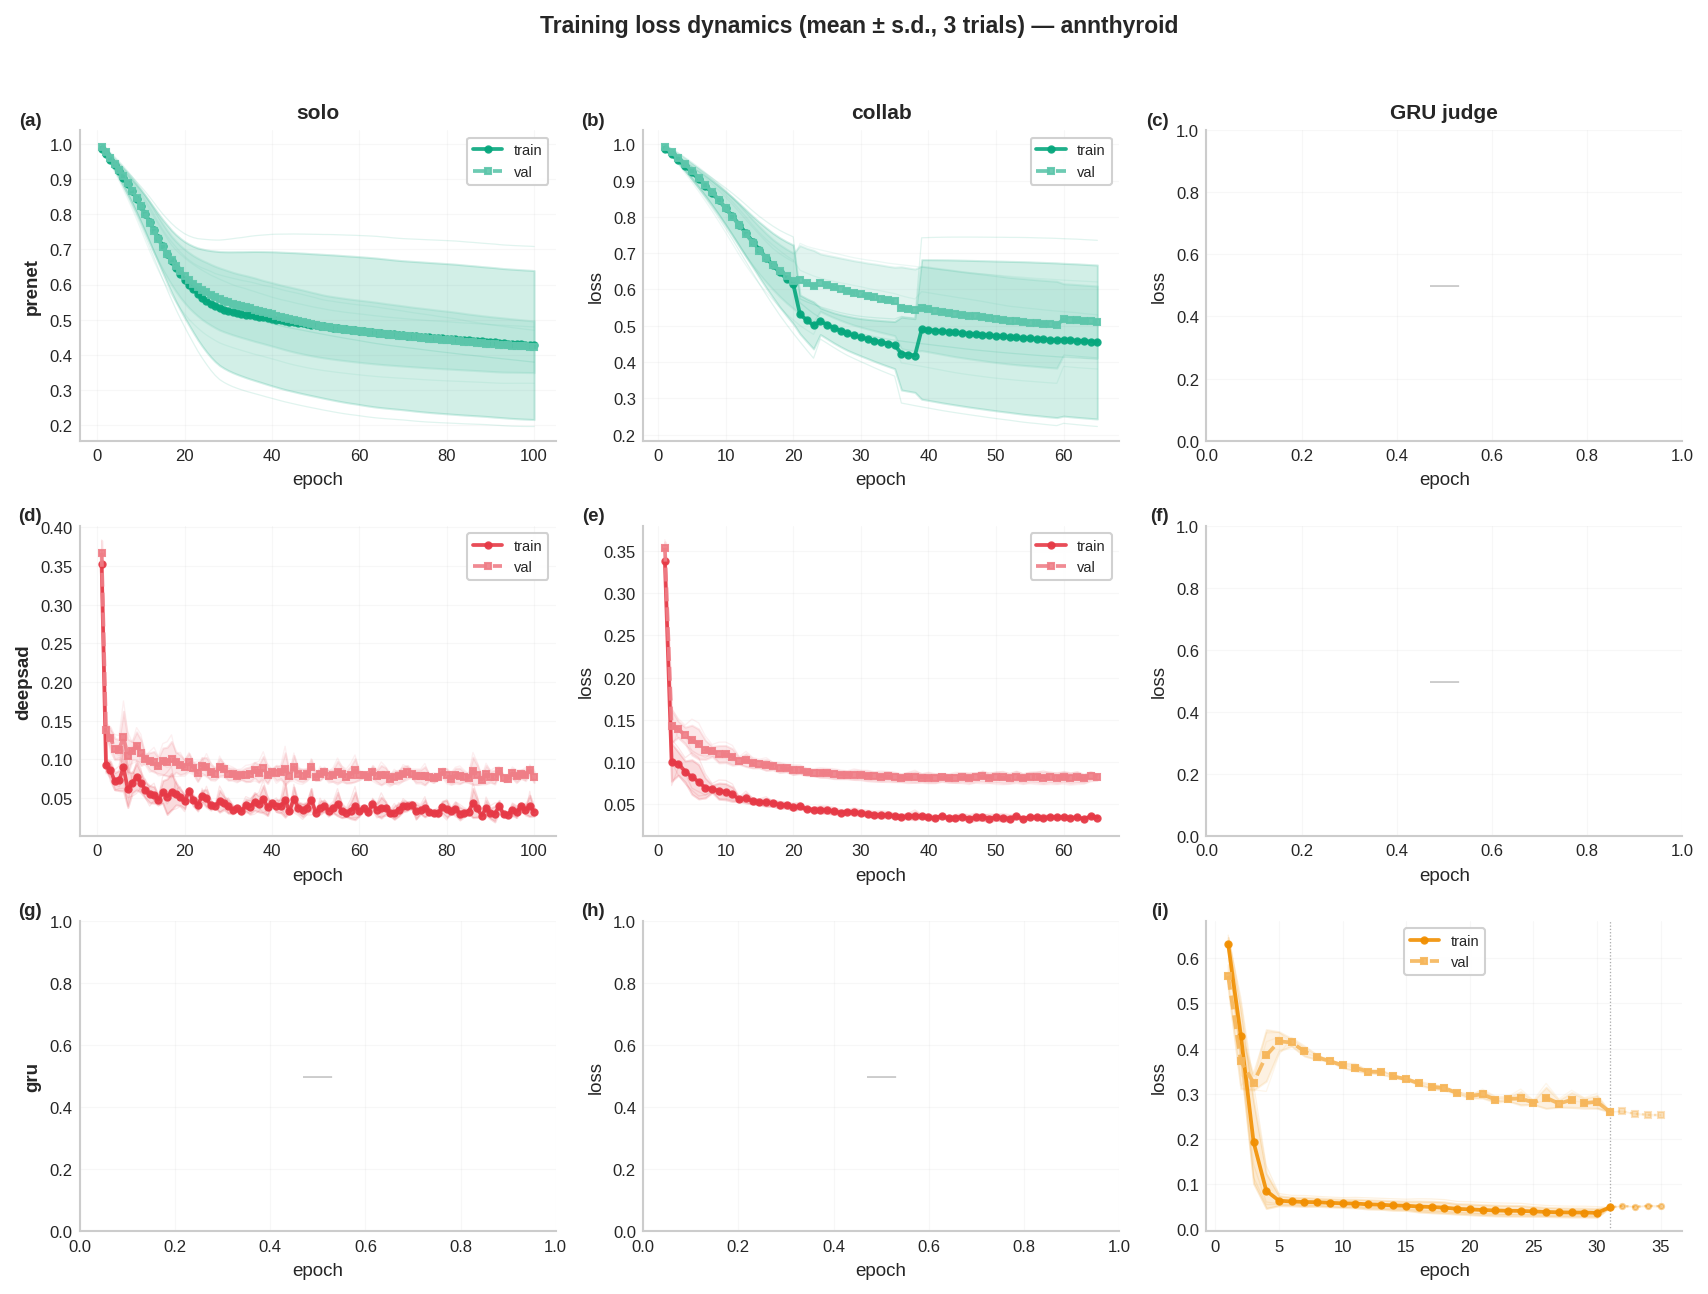

In [ ]:
from plotting import plot_loss_ribbons
fig = plot_loss_ribbons(cv_results, COLORS, DATASET_CONFIG["name"])
plt.show()

/home/peppino58/CoBench/src/plotting.py:87: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/home/peppino58/miniconda3/envs/cobench/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


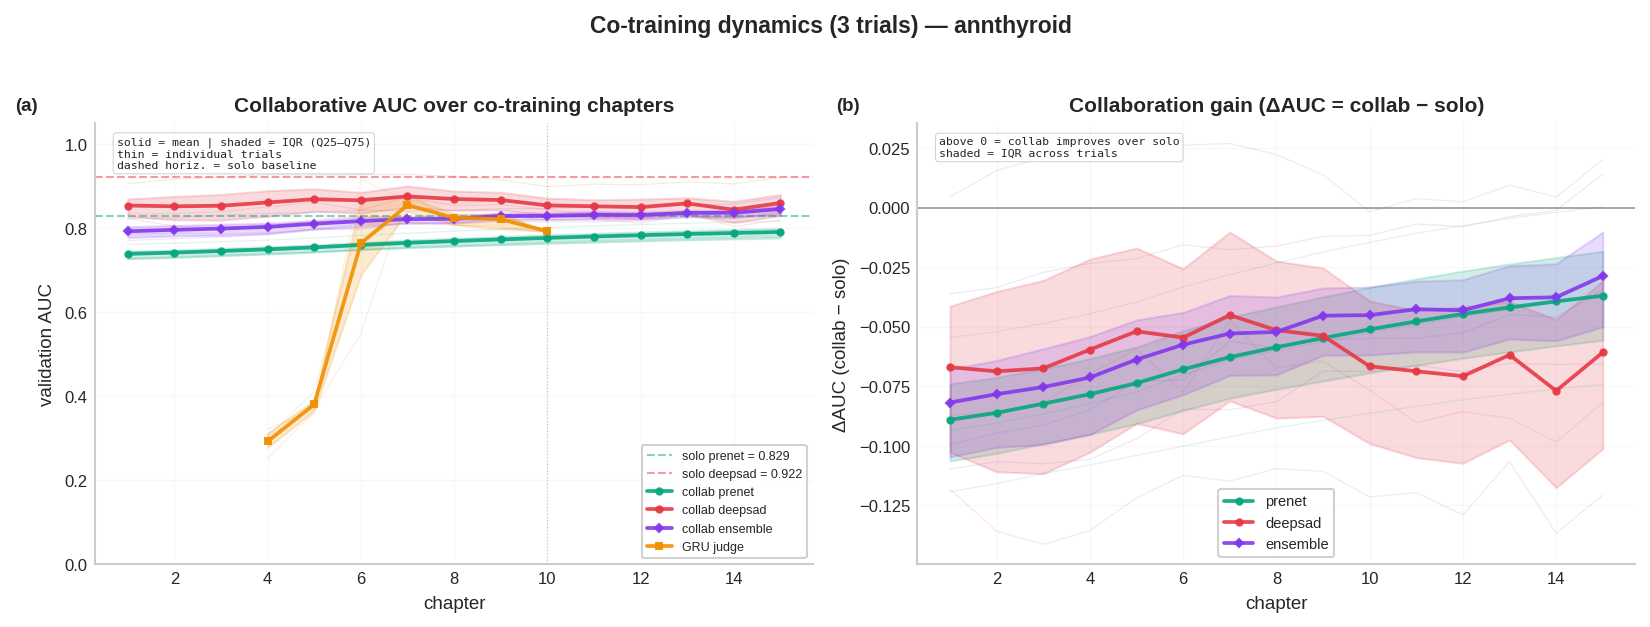

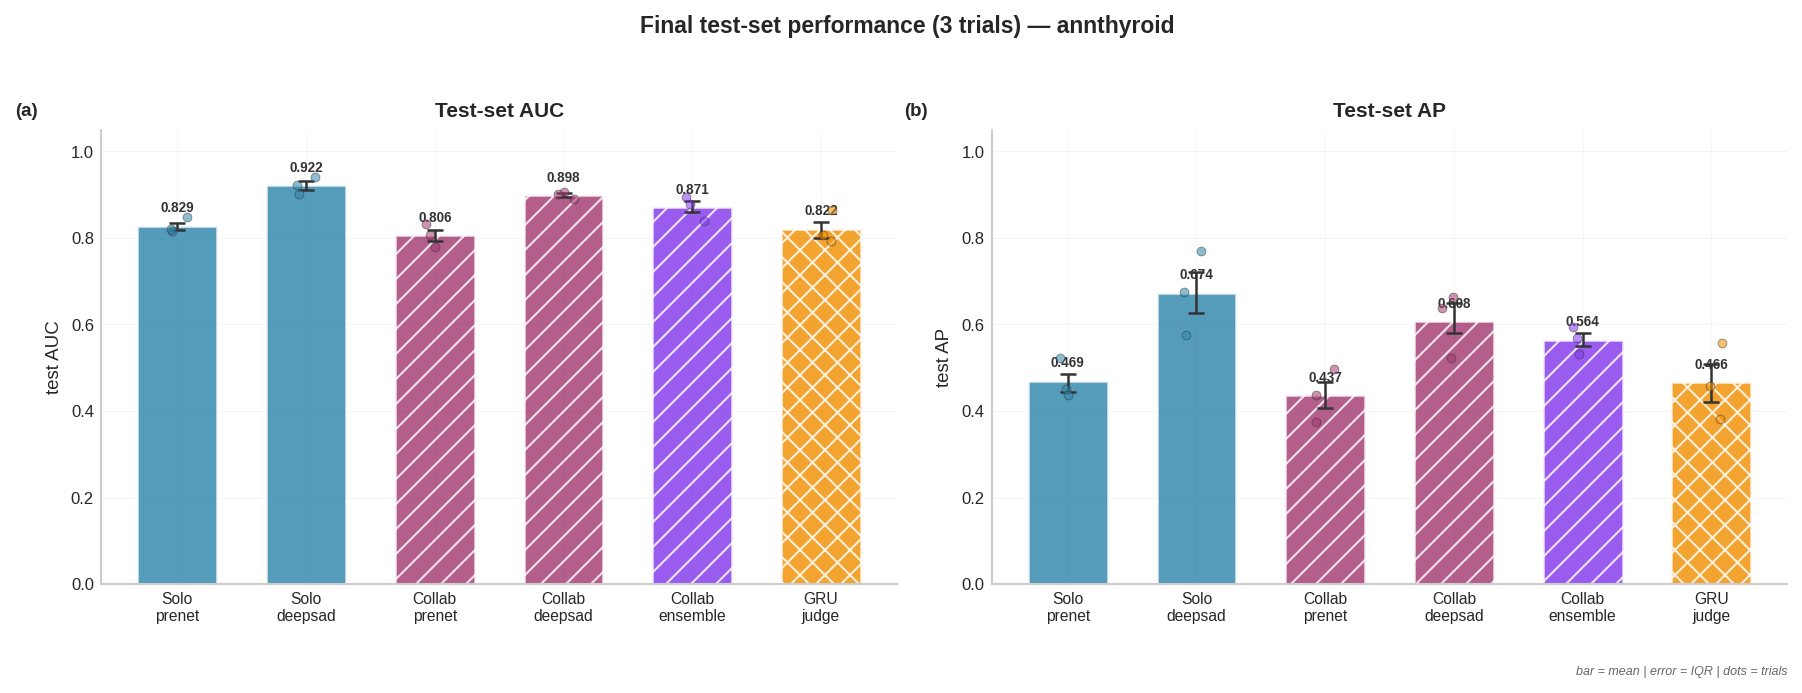

In [ ]:
from plotting import plot_chapter_dynamics, plot_final_bars

fig_dynamics = plot_chapter_dynamics(cv_results, COLORS, DATASET_CONFIG["name"])
plt.show()

fig_barplot = plot_final_bars(cv_results, COLORS, DATASET_CONFIG["name"])
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# EXPORT CV RESULTS
# Filename: {id}.{n_models}.{recurrent}.{colearner}.{strategy}.{models}.csv
# Row 0 is a metadata header (parseable later), then the stats table.
# ══════════════════════════════════════════════════════════════════════
import csv, json, glob
from datetime import datetime

RESULTS_DIR = SRC_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Derive naming components from current config ──
n_models     = len(cv_results["model_names"])
has_recurrent = int(any(not np.isnan(a) for a in cv_results["gru"]["auc"]))
colearner_name  = CoLearnerVal.__name__
strategy_name   = PlateauStrategy.__name__
recurrent_name  = "gru" if has_recurrent else "none"
models_tag      = "-".join(cv_results["model_names"])
if has_recurrent:
    models_tag += f"-{recurrent_name}"
dataset_name = DATASET_CONFIG["name"]

# ── Auto-increment test id (only parse files matching NNN.* pattern) ──
import re as _re
existing_ids = [int(m.group(1)) for f in glob.glob(str(RESULTS_DIR / "*.csv"))
                if (m := _re.match(r"^(\d{3})\.", Path(f).name))]
test_id = max(existing_ids, default=0) + 1

filename = f"{test_id:03d}.{n_models}.{has_recurrent}.{colearner_name}.{strategy_name}.{models_tag}.csv"
filepath = RESULTS_DIR / filename

# ── Build stats table ──
def _stats_row(label, values):
    """Return a dict of summary stats for an array of scores."""
    v = np.array(values, dtype=float)
    return {
        "method": label,
        "mean":  np.nanmean(v),
        "std":   np.nanstd(v),
        "min":   np.nanmin(v),
        "q25":   np.nanpercentile(v, 25),
        "median": np.nanmedian(v),
        "q75":   np.nanpercentile(v, 75),
        "max":   np.nanmax(v),
        "n_trials": int(np.sum(~np.isnan(v))),
    }

rows = []
for name in cv_results["model_names"]:
    rows.append(_stats_row(f"solo_{name}_auc",   cv_results["solo"][name]["auc"]))
    rows.append(_stats_row(f"solo_{name}_ap",    cv_results["solo"][name]["ap"]))
for name in cv_results["model_names"]:
    rows.append(_stats_row(f"collab_{name}_auc", cv_results["collab"][name]["auc"]))
    rows.append(_stats_row(f"collab_{name}_ap",  cv_results["collab"][name]["ap"]))
rows.append(_stats_row("collab_ensemble_auc",    cv_results["collab"]["ensemble"]["auc"]))
rows.append(_stats_row("collab_ensemble_ap",     cv_results["collab"]["ensemble"]["ap"]))
if has_recurrent:
    rows.append(_stats_row("gru_judge_auc",      cv_results["gru"]["auc"]))
    rows.append(_stats_row("gru_judge_ap",       cv_results["gru"]["ap"]))

# Deltas
for name in cv_results["model_names"]:
    da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
    dp = np.array(cv_results["collab"][name]["ap"])  - np.array(cv_results["solo"][name]["ap"])
    rows.append(_stats_row(f"delta_{name}_auc", da))
    rows.append(_stats_row(f"delta_{name}_ap",  dp))

# ── Metadata dict (stored as JSON in row 0) ──
metadata = {
    "test_id": test_id,
    "dataset": dataset_name,
    "dataset_path": str(DATASET_PATH),
    "n_trials": cv_results["n_trials"],
    "seeds": cv_results["seeds"],
    "models": cv_results["model_names"],
    "n_models": n_models,
    "has_recurrent": bool(has_recurrent),
    "recurrent_model": recurrent_name,
    "colearner": colearner_name,
    "strategy": strategy_name,
    "warmup_epochs": CV_WARMUP,
    "max_chapters": CV_MAX_CHAP,
    "epochs_per_chapter": CV_EP_PER_CHAP,
    "gru_start_chapter": CV_GRU_START if has_recurrent else None,
    "train_split": TRAIN_SPLIT,
    "val_test_split": VAL_TEST_SPLIT,
    "semi_label_ratio": SEMI_LABEL_RATIO,
    "timestamp": datetime.now().isoformat(),
}

# ── Write CSV ──
stat_cols = ["method", "mean", "std", "min", "q25", "median", "q75", "max", "n_trials"]
with open(filepath, "w", newline="") as f:
    f.write(f"#META:{json.dumps(metadata)}\n")
    writer = csv.DictWriter(f, fieldnames=stat_cols)
    writer.writeheader()
    for row in rows:
        writer.writerow({k: f"{row[k]:.6f}" if isinstance(row[k], float) else row[k]
                         for k in stat_cols})

# ── Also export raw per-trial values for later re-analysis ──
raw_filepath = filepath.with_suffix(".raw.csv")
raw_cols = ["trial", "seed", "method", "auc", "ap"]
with open(raw_filepath, "w", newline="") as f:
    f.write(f"#META:{json.dumps(metadata)}\n")
    writer = csv.DictWriter(f, fieldnames=raw_cols)
    writer.writeheader()
    for t in range(cv_results["n_trials"]):
        seed_t = cv_results["seeds"][t]
        for name in cv_results["model_names"]:
            writer.writerow({"trial": t, "seed": seed_t, "method": f"solo_{name}",
                             "auc": f"{cv_results['solo'][name]['auc'][t]:.6f}",
                             "ap":  f"{cv_results['solo'][name]['ap'][t]:.6f}"})
        for name in cv_results["model_names"]:
            writer.writerow({"trial": t, "seed": seed_t, "method": f"collab_{name}",
                             "auc": f"{cv_results['collab'][name]['auc'][t]:.6f}",
                             "ap":  f"{cv_results['collab'][name]['ap'][t]:.6f}"})
        writer.writerow({"trial": t, "seed": seed_t, "method": "collab_ensemble",
                         "auc": f"{cv_results['collab']['ensemble']['auc'][t]:.6f}",
                         "ap":  f"{cv_results['collab']['ensemble']['ap'][t]:.6f}"})
        if has_recurrent:
            g_auc_t = cv_results['gru']['auc'][t]
            g_ap_t  = cv_results['gru']['ap'][t]
            writer.writerow({"trial": t, "seed": seed_t, "method": "gru_judge",
                             "auc": "" if np.isnan(g_auc_t) else f"{g_auc_t:.6f}",
                             "ap":  "" if np.isnan(g_ap_t)  else f"{g_ap_t:.6f}"})

print(f"✓ Stats  → {filepath.relative_to(PROJECT_ROOT)}")
print(f"✓ Raw    → {raw_filepath.relative_to(PROJECT_ROOT)}")
print(f"  Filename encodes: test={test_id} | {n_models} models | recurrent={'yes' if has_recurrent else 'no'}")
print(f"  {colearner_name} + {strategy_name} | {models_tag} | {dataset_name}")

✓ Stats  → src/results/010.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.csv
✓ Raw    → src/results/010.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.raw.csv
  Filename encodes: test=10 | 2 models | recurrent=yes
  CoLearnerVal + PlateauStrategy | prenet-deepsad-gru | annthyroid


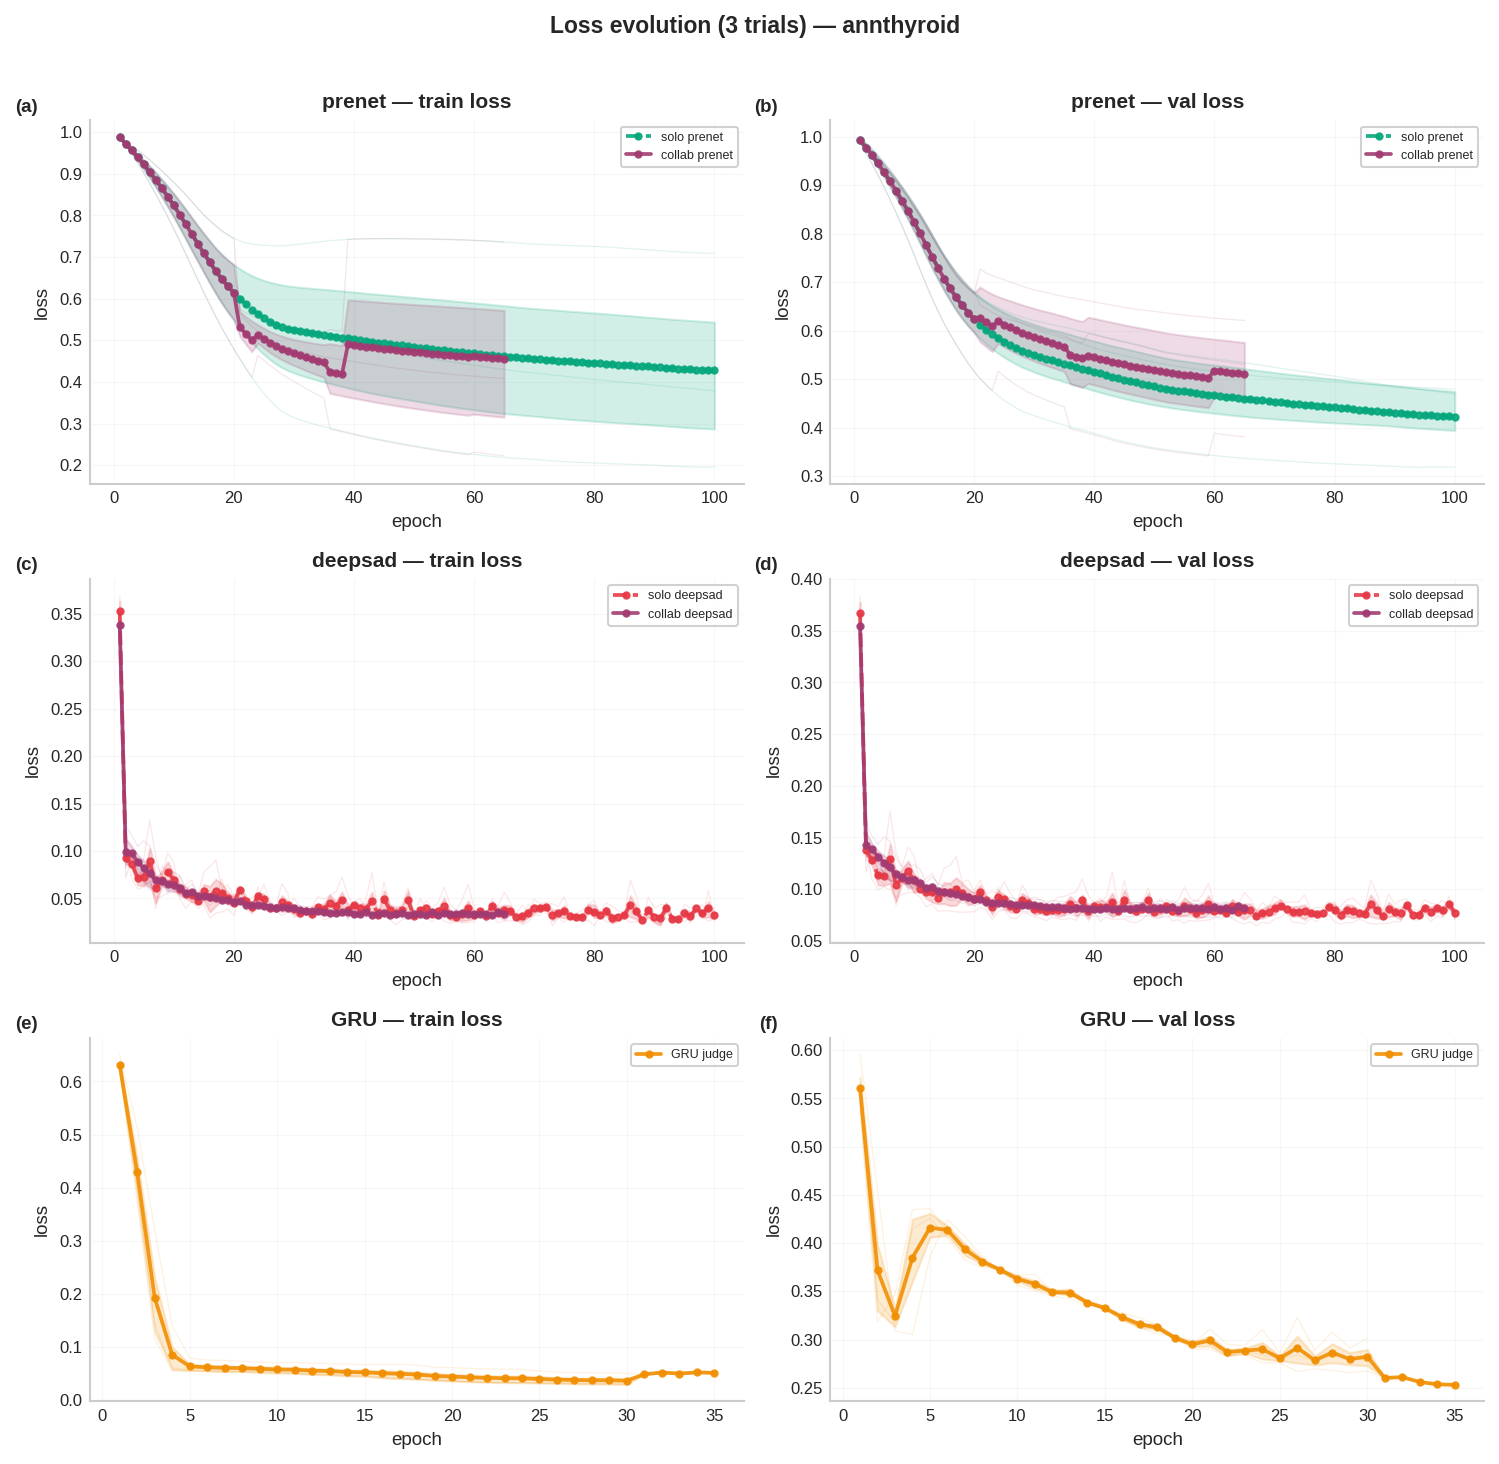

In [ ]:
from plotting import plot_loss_evolution
fig_losses = plot_loss_evolution(cv_results, COLORS, DATASET_CONFIG["name"], has_recurrent=has_recurrent)
plt.show()

In [ ]:
from plotting import save_figures
save_figures(
    {"fig_dynamics": fig_dynamics, "fig_barplot": fig_barplot, "fig_losses": fig_losses},
    filepath, PROJECT_ROOT,
)

✓ fig_dynamics     → src/results/010.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.fig_dynamics.png
✓ fig_barplot      → src/results/010.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.fig_barplot.png
✓ fig_losses       → src/results/010.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.fig_losses.png
